# MEG Brain-State Classification with a Linear-Filter CNN (LF-CNN)

**Deep Learning Project (INFOMDLR)** — Lab Assignment 2

Group Member 
1. Chetlur Vasundhara
2. Ravi Pogaku  
3. Ilayda Taliç  
4. Gayathri S Warrier



In [ ]:
# Importing all the required libraries 

import os, copy, random
import numpy as np
import h5py
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from scipy.signal import decimate
from scipy.stats import zscore
from sklearn.model_selection import StratifiedKFold
from sklearn.manifold import TSNE
from sklearn.metrics import (accuracy_score, f1_score,
                             classification_report, confusion_matrix)

# Reproducibility as we use randomness
def set_seed(seed):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

set_seed(42)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

# importing the data from device
DATA_ROOT  = r"/Users/chetlurvasundhara/Documents/deep learning /Final Project data"
INTRA_PATH = os.path.join(DATA_ROOT, "Intra")
CROSS_PATH = os.path.join(DATA_ROOT, "Cross")

FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)

# each window settings
DOWNSAMPLE_FACTOR = 20      
WINDOW_SIZE       = 200     
TEST_STEP         = 200     
TRAIN_STEP_AUG    = 50      
N_CHANNELS        = 248
CLASS_NAMES       = ["Rest", "Motor", "Working Memory", "Story/Math"]
N_CLASSES         = 4

# The Evaluation settings 
N_FOLDS = 5    # for intra-subject
N_SEEDS = 3    # forcross-subject 

# Training the hyper-parameters 
HP = dict(n_spatial_filters=16, temporal_kernel=25, dropout=0.7)
LR        = 3e-4
L1_LAMBDA = 1e-3
N_EPOCHS  = 100
PATIENCE  = 15
BATCH_SIZE = 32

Using device: cpu


In [2]:
# Preprocessing the data 

def get_label(fname):
    f = fname.lower()
    if "rest" in f:            return 0
    if "motor" in f:           return 1
    if "working_memory" in f:  return 2
    if "story" in f or "math" in f: return 3
    return -1

def get_subject(fname):
    parts = fname.replace(".h5", "").split("_")
    return parts[-2]  # second-to-last token is the subject identifier

def load_files(folder):
    files = []
    for fname in sorted(os.listdir(folder)):
        if not fname.endswith(".h5"):
            continue
        with h5py.File(os.path.join(folder, fname), "r") as f:
            data = f[list(f.keys())[0]][:]            # (248, 35624)
        data = decimate(data, DOWNSAMPLE_FACTOR, axis=1)   # (248, ~1781)
        data = zscore(data, axis=1)                        # per-channel, time-wise
        data = np.nan_to_num(data).astype(np.float32)
        files.append(dict(data=data, label=get_label(fname),
                          subject=get_subject(fname), fname=fname))
    return files

def sliding_window(data, window, step):
    return np.array([data[:, s:s+window]
                     for s in range(0, data.shape[1]-window+1, step)],
                    dtype=np.float32)

def windows_from(files, step):
    X, y = [], []
    for fd in files:
        w = sliding_window(fd["data"], WINDOW_SIZE, step)
        X.append(w); y.extend([fd["label"]] * len(w))
    return np.concatenate(X, axis=0), np.array(y, dtype=np.int64)

# Loading all intra-subject data at once
intra_train_files = load_files(os.path.join(INTRA_PATH, "train"))
intra_test_files  = load_files(os.path.join(INTRA_PATH, "test"))
intra_files       = intra_train_files + intra_test_files       # pooled for 5-fold CV

# Loading all cross-subject data at once
cross_train_files = load_files(os.path.join(CROSS_PATH, "train"))
cross_test_sets   = {                                          # keep subjects separate
    "Subject 1 (test1)": load_files(os.path.join(CROSS_PATH, "test1")),
    "Subject 2 (test2)": load_files(os.path.join(CROSS_PATH, "test2")),
    "Subject 3 (test3)": load_files(os.path.join(CROSS_PATH, "test3")),
}

print(f"Intra files: {len(intra_files)} (train {len(intra_train_files)} + test {len(intra_test_files)})")
print(f"Cross train files: {len(cross_train_files)} | train subjects: "
      f"{sorted(set(fd['subject'] for fd in cross_train_files))}")
for name, fs in cross_test_sets.items():
    print(f"  {name}: {len(fs)} files | subject(s): {sorted(set(fd['subject'] for fd in fs))}")

Intra files: 40 (train 32 + test 8)
Cross train files: 64 | train subjects: ['113922', '164636']
  Subject 1 (test1): 16 files | subject(s): ['162935']
  Subject 2 (test2): 16 files | subject(s): ['707749']
  Subject 3 (test3): 16 files | subject(s): ['725751', '735148']


In [3]:
# augment the data 

def augment_signal(x, noise_std=0.1, max_shift=20,
                   p_channel_drop=0.1, amp_jitter=0.1):
    """x: (C, T) float tensor -> augmented (C, T)."""
    x = x + noise_std * torch.randn_like(x)                       
    x = x * (1.0 + amp_jitter * (2*torch.rand(1).item() - 1))     
    shift = int(torch.randint(-max_shift, max_shift+1, (1,)).item())
    x = torch.roll(x, shifts=shift, dims=-1)     
    # channel dropout                 
    if p_channel_drop > 0:                                        
        mask = (torch.rand(x.shape[0], 1) > p_channel_drop).float()
        x = x * mask
    return x

class WindowDataset(Dataset):
    """Wraps (X, y); adds the channel dim and (optionally) augments on the fly."""
    def __init__(self, X, y, augment=False, **aug_kwargs):
        self.X = torch.tensor(X, dtype=torch.float32)   
        self.y = torch.tensor(y, dtype=torch.long)
        self.augment = augment
        self.aug_kwargs = aug_kwargs
    def __len__(self):  return len(self.y)
    def __getitem__(self, i):
        x = self.X[i]
        if self.augment:
            x = augment_signal(x, **self.aug_kwargs)
        return x.unsqueeze(0), self.y[i]                 

def make_loader(X, y, shuffle=True, augment=False):
    ds = WindowDataset(X, y, augment=augment)
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle)

In [ ]:
# model initialzation LF_CNN

class LFCNN(nn.Module):
    def __init__(self, n_channels=248, n_spatial_filters=16, temporal_kernel=25,
                 pool_size=2, dropout=0.7, n_classes=4):
        super().__init__()
        # Layer 1 — spatial filter
        self.spatial_filter = nn.Conv2d(1, n_spatial_filters,
                                        kernel_size=(n_channels, 1), bias=False)
        # Layer 2 — depthwise temporal filter
        self.temporal_filter = nn.Conv1d(n_spatial_filters, n_spatial_filters,
                                         kernel_size=temporal_kernel,
                                         padding=temporal_kernel // 2,
                                         groups=n_spatial_filters, bias=False)
        self.activation = nn.ReLU()
        self.pool       = nn.MaxPool1d(pool_size, pool_size)
        self.dropout    = nn.Dropout(dropout)
        self.gap        = nn.AdaptiveAvgPool1d(1)              
        self.classifier = nn.Linear(n_spatial_filters, n_classes)

    def features(self, x):                                     
        x = self.spatial_filter(x).squeeze(2)                  
        x = self.activation(self.temporal_filter(x))           
        x = self.pool(x)
        x = self.dropout(x)
        x = self.gap(x).squeeze(-1)                            
        return x

    def forward(self, x):
        return self.classifier(self.features(x))

# sanity check
_m = LFCNN(**HP)
print("Output shape:", _m(torch.zeros(4, 1, N_CHANNELS, WINDOW_SIZE)).shape,
      "| parameters:", sum(p.numel() for p in _m.parameters()))

Output shape: torch.Size([4, 4]) | parameters: 4436


In [5]:
# training and evaluation functions

def train_model(model, train_loader, val_loader,
                n_epochs=N_EPOCHS, lr=LR, l1_lambda=L1_LAMBDA,
                patience=PATIENCE, verbose=False):
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    best_val, best_state, ctr = float("inf"), None, 0
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(n_epochs):
        # train 
        model.train(); loss_sum = correct = total = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb) + l1_lambda * model.classifier.weight.abs().sum()
            loss.backward(); optimizer.step()
            loss_sum += loss.item() * xb.size(0)
            correct  += (logits.argmax(1) == yb).sum().item(); total += xb.size(0)
        history["train_loss"].append(loss_sum/total)
        history["train_acc"].append(correct/total)

        # validate
        model.eval(); v_loss = v_correct = v_total = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                logits = model(xb); loss = criterion(logits, yb)
                v_loss   += loss.item() * xb.size(0)
                v_correct += (logits.argmax(1) == yb).sum().item(); v_total += xb.size(0)
        vl = v_loss/v_total
        history["val_loss"].append(vl); history["val_acc"].append(v_correct/v_total)
        if verbose and (epoch+1) % 20 == 0:
            print(f"  epoch {epoch+1:3d} | train {history['train_acc'][-1]:.3f}"
                  f" | val {history['val_acc'][-1]:.3f}")

        # early stopping to prevent overfitting
        if vl < best_val - 1e-5:
            best_val, best_state, ctr = vl, {k: v.clone() for k, v in model.state_dict().items()}, 0
        else:
            ctr += 1
            if ctr >= patience: break
    if best_state: model.load_state_dict(best_state)
    return model, history

@torch.no_grad()
def predict(model, loader):
    model.eval(); preds, labels = [], []
    for xb, yb in loader:
        preds.extend(model(xb.to(DEVICE)).argmax(1).cpu().numpy())
        labels.extend(yb.numpy())
    return np.array(preds), np.array(labels)

@torch.no_grad()
def extract_features(model, loader):
    model.eval(); F, L = [], []
    for xb, yb in loader:
        F.append(model.features(xb.to(DEVICE)).cpu().numpy()); L.extend(yb.numpy())
    return np.concatenate(F), np.array(L)

In [6]:
# Experiemnt A - Intra Subject
def run_intra_cv(files, n_folds=N_FOLDS, train_step=TEST_STEP,
                 augment=False, seed=42):
    set_seed(seed)
    labels = np.array([fd["label"] for fd in files])
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)
    fold_tr, fold_te, P, L, last_hist = [], [], [], [], None

    for k, (tr_idx, te_idx) in enumerate(skf.split(np.arange(len(files)), labels)):
        tr_files = [files[i] for i in tr_idx]
        te_files = [files[i] for i in te_idx]
        Xtr, ytr = windows_from(tr_files, train_step)   # overlap if augmenting
        Xte, yte = windows_from(te_files, TEST_STEP)     # always non-overlapping

        model = LFCNN(**HP)
        model, hist = train_model(model,
                                  make_loader(Xtr, ytr, shuffle=True, augment=augment),
                                  make_loader(Xte, yte, shuffle=False))
        last_hist = hist
        ptr, ltr = predict(model, make_loader(Xtr, ytr, shuffle=False))
        pte, lte = predict(model, make_loader(Xte, yte, shuffle=False))
        fold_tr.append(accuracy_score(ltr, ptr)); fold_te.append(accuracy_score(lte, pte))
        P.extend(pte); L.extend(lte)
        print(f"  Fold {k+1}/{n_folds} | train {fold_tr[-1]:.3f} | test {fold_te[-1]:.3f}")

    return dict(train_mean=np.mean(fold_tr), train_std=np.std(fold_tr),
                test_mean=np.mean(fold_te), test_std=np.std(fold_te),
                fold_test=fold_te, preds=np.array(P), labels=np.array(L),
                history=last_hist)

print("=== Intra-subject — BASELINE (non-overlapping, no augmentation) ===")
intra_baseline = run_intra_cv(intra_files, train_step=TEST_STEP, augment=False)
print(f"\nIntra test accuracy: {intra_baseline['test_mean']:.4f} "
      f"+/- {intra_baseline['test_std']:.4f}")

=== Intra-subject — BASELINE (non-overlapping, no augmentation) ===
  Fold 1/5 | train 0.938 | test 0.547
  Fold 2/5 | train 0.863 | test 0.547
  Fold 3/5 | train 0.652 | test 0.312
  Fold 4/5 | train 0.867 | test 0.469
  Fold 5/5 | train 0.785 | test 0.516

Intra test accuracy: 0.4781 +/- 0.0876


In [7]:
# Experiment B - Cross Subject 

def run_cross(train_files, test_sets, n_seeds=N_SEEDS,
              train_step=TEST_STEP, augment=False):
    per_subject = {name: [] for name in test_sets}     
    overall, last = [], {}
    # pre-build non-overlapping test windows per subject (fixed across seeds)
    test_loaders = {name: make_loader(*windows_from(fs, TEST_STEP), shuffle=False)
                    for name, fs in test_sets.items()}

    for s in range(n_seeds):
        set_seed(s)
        # reproducible 10% file-level validation split for early stopping
        idx = np.arange(len(train_files)); np.random.shuffle(idx)
        n_val = max(1, len(train_files)//10)
        val_files = [train_files[i] for i in idx[:n_val]]
        tr_files  = [train_files[i] for i in idx[n_val:]]
        Xtr, ytr = windows_from(tr_files,  train_step)   
        Xva, yva = windows_from(val_files, TEST_STEP)

        model = LFCNN(**HP)
        model, hist = train_model(model,
                                  make_loader(Xtr, ytr, shuffle=True, augment=augment),
                                  make_loader(Xva, yva, shuffle=False))

        # per-subject + pooled test accuracy
        all_p, all_l = [], []
        for name, loader in test_loaders.items():
            p, l = predict(model, loader)
            per_subject[name].append(accuracy_score(l, p))
            all_p.extend(p); all_l.extend(l)
        overall.append(accuracy_score(all_l, all_p))
        # also a train-accuracy snapshot (last seed) for the train/test gap
        ptr, ltr = predict(model, make_loader(Xtr, ytr, shuffle=False))
        last = dict(history=hist, preds=np.array(all_p), labels=np.array(all_l),
                    train_acc=accuracy_score(ltr, ptr), model=model,
                    test_loaders=test_loaders)
        print(f"  seed {s} | overall test {overall[-1]:.3f}")

    res = dict(test_mean=np.mean(overall), test_std=np.std(overall),
               per_subject={k: (np.mean(v), np.std(v)) for k, v in per_subject.items()},
               **last)
    return res

print("=== Cross-subject — BASELINE (non-overlapping, no augmentation) ===")
cross_baseline = run_cross(cross_train_files, cross_test_sets,
                           train_step=TEST_STEP, augment=False)
print(f"\nCross test accuracy: {cross_baseline['test_mean']:.4f} "
      f"+/- {cross_baseline['test_std']:.4f}")
for name, (m, sd) in cross_baseline["per_subject"].items():
    print(f"  {name}: {m:.4f} +/- {sd:.4f}")

=== Cross-subject — BASELINE (non-overlapping, no augmentation) ===
  seed 0 | overall test 0.586
  seed 1 | overall test 0.562
  seed 2 | overall test 0.581

Cross test accuracy: 0.5764 +/- 0.0100
  Subject 1 (test1): 0.5286 +/- 0.0037
  Subject 2 (test2): 0.5156 +/- 0.0110
  Subject 3 (test3): 0.6849 +/- 0.0390


  spatial= 8, temporal_kernel= 7 -> acc 0.484
  spatial= 8, temporal_kernel=15 -> acc 0.531
  spatial= 8, temporal_kernel=25 -> acc 0.297
  spatial= 8, temporal_kernel=35 -> acc 0.531
  spatial=16, temporal_kernel= 7 -> acc 0.531
  spatial=16, temporal_kernel=15 -> acc 0.469
  spatial=16, temporal_kernel=25 -> acc 0.547
  spatial=16, temporal_kernel=35 -> acc 0.438
  spatial=32, temporal_kernel= 7 -> acc 0.516
  spatial=32, temporal_kernel=15 -> acc 0.516
  spatial=32, temporal_kernel=25 -> acc 0.438
  spatial=32, temporal_kernel=35 -> acc 0.500


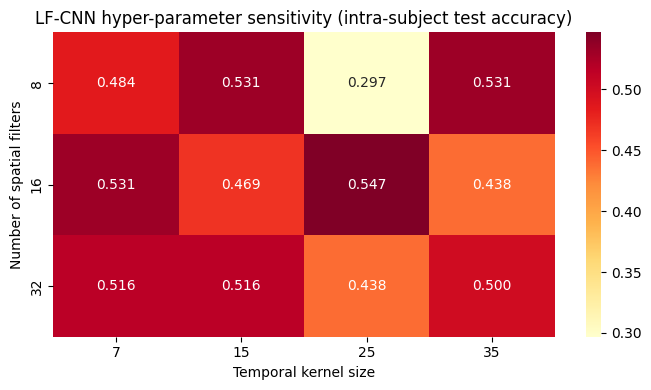

In [8]:
# Question c - Hyper-parameter sensitivity

def quick_eval(n_sf, tk, seed=42):
    set_seed(seed)
    Xtr, ytr = windows_from(intra_train_files, TEST_STEP)
    Xte, yte = windows_from(intra_test_files,  TEST_STEP)
    model = LFCNN(n_spatial_filters=n_sf, temporal_kernel=tk, dropout=HP["dropout"])
    model, _ = train_model(model,
                           make_loader(Xtr, ytr, shuffle=True),
                           make_loader(Xte, yte, shuffle=False))
    p, l = predict(model, make_loader(Xte, yte, shuffle=False))
    return accuracy_score(l, p)

spatial_filters  = [8, 16, 32]
temporal_kernels = [7, 15, 25, 35]
grid = np.zeros((len(spatial_filters), len(temporal_kernels)))
for i, sf in enumerate(spatial_filters):
    for j, tk in enumerate(temporal_kernels):
        grid[i, j] = quick_eval(sf, tk)
        print(f"  spatial={sf:2d}, temporal_kernel={tk:2d} -> acc {grid[i,j]:.3f}")

plt.figure(figsize=(7, 4))
sns.heatmap(grid, annot=True, fmt=".3f", cmap="YlOrRd",
            xticklabels=temporal_kernels, yticklabels=spatial_filters)
plt.xlabel("Temporal kernel size"); plt.ylabel("Number of spatial filters")
plt.title("LF-CNN hyper-parameter sensitivity (intra-subject test accuracy)")
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/fig_hparam_heatmap.png", dpi=200); plt.show()

In [9]:
# Question d - Improved training strategies 

print("=== Intra-subject — IMPROVED (overlapping windows + augmentation) ===")
intra_aug = run_intra_cv(intra_files, train_step=TRAIN_STEP_AUG, augment=True)
print(f"Intra (improved): {intra_aug['test_mean']:.4f} +/- {intra_aug['test_std']:.4f}\n")

print("=== Cross-subject — IMPROVED (overlapping windows + augmentation) ===")
cross_aug = run_cross(cross_train_files, cross_test_sets,
                      train_step=TRAIN_STEP_AUG, augment=True)
print(f"Cross (improved): {cross_aug['test_mean']:.4f} +/- {cross_aug['test_std']:.4f}")

print("\n--- Before / after ---")
print(f"Intra : {intra_baseline['test_mean']:.3f} -> {intra_aug['test_mean']:.3f}")
print(f"Cross : {cross_baseline['test_mean']:.3f} -> {cross_aug['test_mean']:.3f}")

=== Intra-subject — IMPROVED (overlapping windows + augmentation) ===
  Fold 1/5 | train 0.992 | test 0.594
  Fold 2/5 | train 0.918 | test 0.656
  Fold 3/5 | train 0.669 | test 0.375
  Fold 4/5 | train 0.798 | test 0.500
  Fold 5/5 | train 0.899 | test 0.641
Intra (improved): 0.5531 +/- 0.1044

=== Cross-subject — IMPROVED (overlapping windows + augmentation) ===
  seed 0 | overall test 0.594
  seed 1 | overall test 0.542
  seed 2 | overall test 0.581
Cross (improved): 0.5720 +/- 0.0221

--- Before / after ---
Intra : 0.478 -> 0.553
Cross : 0.576 -> 0.572


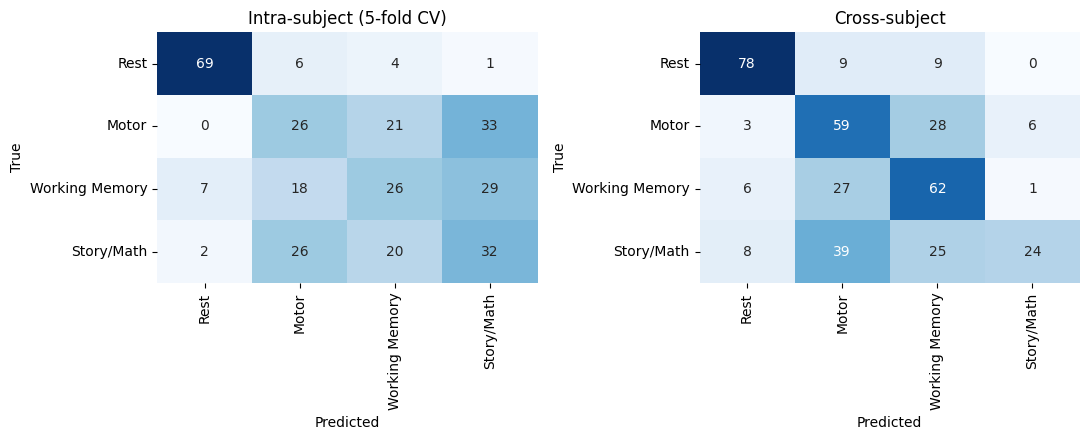

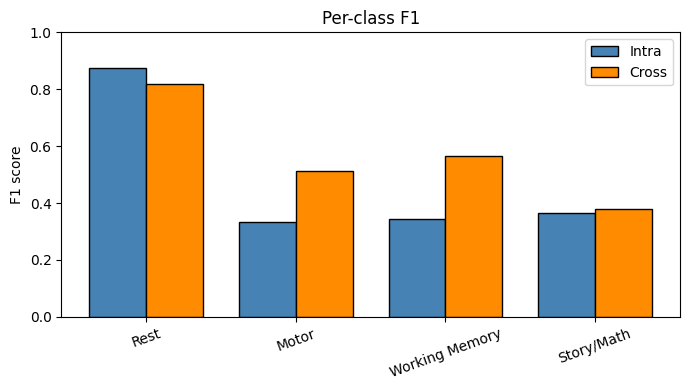

In [10]:
# ---- Fig 2: confusion matrices (Question b) ----------------------------------
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (res, title) in zip(axes, [(intra_baseline, "Intra-subject (5-fold CV)"),
                                    (cross_baseline, "Cross-subject")]):
    cm = confusion_matrix(res["labels"], res["preds"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_title(title); ax.set_xlabel("Predicted"); ax.set_ylabel("True")
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/fig_confusion.png", dpi=200); plt.show()

# ---- per-class F1 (referenced in the per-class analysis) ---------------------
f1_intra = f1_score(intra_baseline["labels"], intra_baseline["preds"], average=None)
f1_cross = f1_score(cross_baseline["labels"], cross_baseline["preds"], average=None)
x = np.arange(N_CLASSES); w = 0.38
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x-w/2, f1_intra, w, label="Intra", color="steelblue", edgecolor="black")
ax.bar(x+w/2, f1_cross, w, label="Cross", color="darkorange", edgecolor="black")
ax.set_xticks(x); ax.set_xticklabels(CLASS_NAMES, rotation=20)
ax.set_ylabel("F1 score"); ax.set_ylim(0, 1); ax.set_title("Per-class F1"); ax.legend()
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/fig_per_class_f1.png", dpi=200); plt.show()

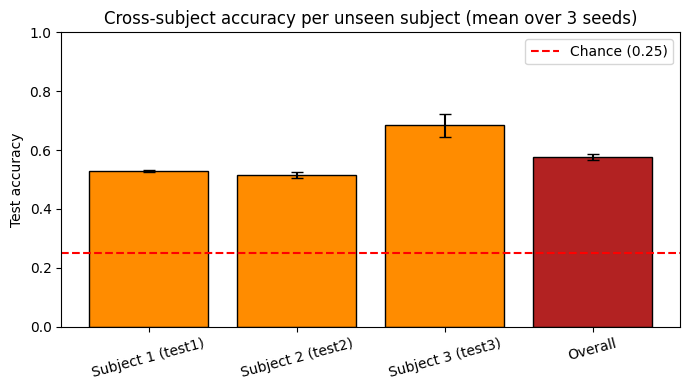

In [11]:
# ---- Fig 3: per-test-subject accuracy (Question b/d) -------------------------
subs = list(cross_baseline["per_subject"])
means = [cross_baseline["per_subject"][s][0] for s in subs]
stds  = [cross_baseline["per_subject"][s][1] for s in subs]
subs_plot = subs + ["Overall"]
means += [cross_baseline["test_mean"]]; stds += [cross_baseline["test_std"]]
fig, ax = plt.subplots(figsize=(7, 4))
colors = ["darkorange"]*len(subs) + ["firebrick"]
ax.bar(subs_plot, means, yerr=stds, capsize=4, color=colors, edgecolor="black")
ax.axhline(0.25, color="red", ls="--", label="Chance (0.25)")
ax.set_ylabel("Test accuracy"); ax.set_ylim(0, 1)
ax.set_title(f"Cross-subject accuracy per unseen subject (mean over {N_SEEDS} seeds)")
ax.legend(); plt.xticks(rotation=15)
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/fig_per_subject.png", dpi=200); plt.show()

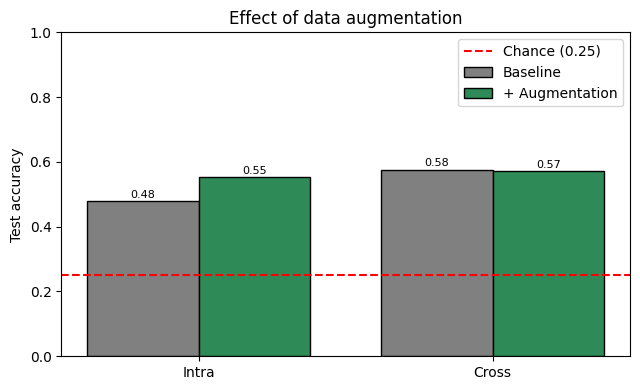

In [12]:
# ---- Fig 4: improvement before/after (Question d) ----------------------------
labels_ = ["Intra", "Cross"]
before  = [intra_baseline["test_mean"], cross_baseline["test_mean"]]
after   = [intra_aug["test_mean"],      cross_aug["test_mean"]]
x = np.arange(2); w = 0.38
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.bar(x-w/2, before, w, label="Baseline", color="gray", edgecolor="black")
ax.bar(x+w/2, after,  w, label="+ Augmentation", color="seagreen", edgecolor="black")
ax.axhline(0.25, color="red", ls="--", label="Chance (0.25)")
ax.set_xticks(x); ax.set_xticklabels(labels_); ax.set_ylabel("Test accuracy")
ax.set_ylim(0, 1); ax.set_title("Effect of data augmentation"); ax.legend()
for xi, (a, b) in enumerate(zip(before, after)):
    ax.text(xi-w/2, a+.01, f"{a:.2f}", ha="center", fontsize=8)
    ax.text(xi+w/2, b+.01, f"{b:.2f}", ha="center", fontsize=8)
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/fig_improvement.png", dpi=200); plt.show()

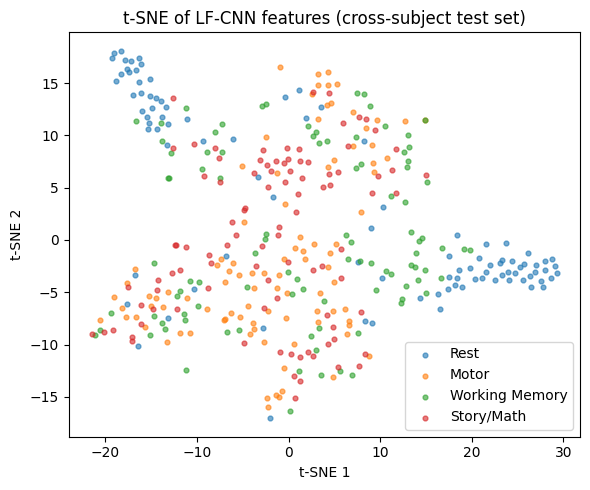

In [13]:
# ----  t-SNE of learned features (Question d) -------------------
model = cross_baseline["model"]
loaders = cross_baseline["test_loaders"]
F_all, L_all = [], []
for loader in loaders.values():
    f, l = extract_features(model, loader); F_all.append(f); L_all.append(l)
F_all = np.concatenate(F_all); L_all = np.concatenate(L_all)
emb = TSNE(n_components=2, perplexity=30, random_state=42,
           init="pca").fit_transform(F_all)
plt.figure(figsize=(6, 5))
for c in range(N_CLASSES):
    m = L_all == c
    plt.scatter(emb[m, 0], emb[m, 1], s=12, alpha=0.6, label=CLASS_NAMES[c])
plt.legend(); plt.title("t-SNE of LF-CNN features (cross-subject test set)")
plt.xlabel("t-SNE 1"); plt.ylabel("t-SNE 2")
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/fig_tsne.png", dpi=200); plt.show()

## 11. Final results summary

In [14]:
gap_intra = intra_baseline["train_mean"] - intra_baseline["test_mean"]
gap_cross = cross_baseline["train_acc"]  - cross_baseline["test_mean"]

print("="*60)
print(f"{'Setting':<22}{'Train':>9}{'Test':>9}{'Test (aug)':>13}")
print("-"*60)
print(f"{'Intra-subject':<22}{intra_baseline['train_mean']:>9.3f}"
      f"{intra_baseline['test_mean']:>9.3f}{intra_aug['test_mean']:>13.3f}")
print(f"{'Cross-subject':<22}{cross_baseline['train_acc']:>9.3f}"
      f"{cross_baseline['test_mean']:>9.3f}{cross_aug['test_mean']:>13.3f}")
print("="*60)
print(f"Train-test gap  | intra {gap_intra:.3f} | cross {gap_cross:.3f}")
print(f"Figures saved to ./{FIG_DIR}/:")
for f in ["fig_model_comparison","fig_confusion","fig_per_class_f1",
          "fig_per_subject","fig_hparam_heatmap","fig_improvement","fig_tsne"]:
    print(f"  - {f}.png")

Setting                   Train     Test   Test (aug)
------------------------------------------------------------
Intra-subject             0.821    0.478        0.553
Cross-subject             0.959    0.576        0.572
Train-test gap  | intra 0.343 | cross 0.383
Figures saved to ./figures/:
  - fig_model_comparison.png
  - fig_confusion.png
  - fig_per_class_f1.png
  - fig_per_subject.png
  - fig_hparam_heatmap.png
  - fig_improvement.png
  - fig_tsne.png


## Contributions

Each team memeber individually, researched and worked on four different models. Based on the model's performance we decided LF-CNN as our primary. We then proceeded to work on the report togther. 